# HUM-450 Preliminary Analysis
The goal of this notebooks is to develop and test analysis tool for the project

In [189]:
import numpy as np
import pandas as pd
import os
import re
from collections import Counter, defaultdict
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap
import folium
from folium.plugins import MarkerCluster
import geopy
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from Levenshtein import distance as levenshtein_distance
import spacy
from spacy.lang.fr.stop_words import STOP_WORDS
import string
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer
tb = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())
import plotly.graph_objects as go
import plotly.express as px
import csv

# Download the stopwords
nltk.download('stopwords')

# Path to the data folder
# ROOT="C:/Users/lolon/OneDrive/EPFL/RO-1ST YEAR 2023-2024/SHS/HUM-450_part_2/HUM-450"
ROOT="/Users/selmabenhassine/Desktop/MA2/SHS/HUM-450"
path_data=ROOT+"/data/data_Impresso"

# Year, party, query word to change
year = "1890-1910"
party = "PPC"
query = ["parti", "union", "conservatrice", "populaire", "catholique", "PCP", "PPC"]

# Path to results folder
results_data = ROOT + f"/data/data_Language/{year}/{party}"


# File name
#file_name = "1890_1910_PartiSocialiste_PartiSocialisteSuisse_PSS"
#file_name = "1890_1910_Radicaux_PartiRadicalDemocratique_GaucheRadicale_GR_PRD"
file_name = "1890_1910_UnionConservatrice_PartiPopulaireCatholique"

#file_name = "1945_1960_PartiDesPaysansArtisansEtIndependants_PAI_PartiDesPaysansArtisansBourgeois_PAB"
#file_name = "1945_1965_PartiConservateurPopulaire_PCP"
#file_name = "1945_1965_PartiRadical-Democratique_PRD"
#file_name = "1945_1965_PartiSocialiste_PSS"

#file_name = "1966_1980_PAB_PAI_UDC_UnionDemocratiqueDuCentre"
#file_name = "1966_1980_PDC_PartiDemocrateCHretien_PCCS_PartiConservateurChretienSocial"
#file_name = "1966_1980_PRD_PartiRadicalDemocratique_GR_radicaux"
#file_name = "1966_1980_PSS_PartiSocialiste"

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/selmabenhassine/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [190]:
def load_database(path):
    """
    Simple method for loading the database
    """
    database = pd.read_csv(path, sep=';')
    database['persons_mentioned']=database['persons_mentioned'].apply(lambda x: x if pd.isnull(x) else x[1:-1].replace("'", '').replace(", ",",").split(','))
    database['locations_mentioned']=database['locations_mentioned'].apply(lambda x: x if pd.isnull(x) else x[1:-1].replace("'", '').replace(", ",",").split(','))
    return database




In [191]:
adjectives = pd.read_csv(ROOT+"/data"+f"/adj.csv", sep=',')
adjectives = adjectives['form']
#apply(lambda x: x if pd.isnull(x) else x[1:-1].replace("'", '').replace(", ",",").split(','))
adjective_list = []
for adj in adjectives:
    adjective_list.append(adj)
print(len(adjective_list))

49091


In [192]:
#Load the data
extraction=load_database(path_data+f"/{year}/{file_name}.csv")
extraction.head()
#print(extraction.shape)
print(extraction.date[0][:4])



1891


## Token occurence analysis

In [193]:
# Function to filter out words with only two letters of difference
def filter_similar_words(words):
    filtered_words = []
    for word in words:
        if not any(levenshtein_distance(word, filtered_word) <= 2 for filtered_word in filtered_words):
            filtered_words.append(word)
    return filtered_words

In [194]:
# Define a regular expression pattern for French letters
french_letters_pattern = re.compile(r'^[a-zA-ZÀ-ÿ]+$')

# French stopwords provided by NLTK
french_stopwords = set(stopwords.words('french'))

#Extract the token
N_token=10
extratced_string_before=[]
extratced_string_after=[]
relevant_years=[]

for i in range(0, extraction.shape[0]):
    #Prepare the data
    token=str.lower(extraction.content[i])
    token=re.sub(r'[();,"|%\'\'$*&:«».#^/<>+-]', ' ', token)
    token=re.split(r'\s+', token)
    white_ind=[]
    for j in range(0,len(token)):
        if (token[j]!=''):
            white_ind.append(int(j))
    token=np.take(token, white_ind, 0)

    # Filter out words that do not contain only French letters
    token = [word for word in token if french_letters_pattern.match(word)] 

    # # Filter out stopwords
    token = [word for word in token if word not in french_stopwords]

    # Split each token further into individual words
    sentence=[]
    token = [word for sublist in token for word in sublist.split()]
    sentence.append(token)

    #Findex the indexes
    indexes=[]
    for j in range(len(sentence[0])):
        # Check if the current index is already within N_token distance of another index
        if not any(abs(j - existing_index) < N_token for existing_index in indexes):
            # Ensure we check within bounds
            if (sentence[0][j] in query and
                ( (j-2 >= 0 and sentence[0][j-2] in query) or
                  (j-1 >= 0 and sentence[0][j-1] in query) or
                  (j+1 < len(sentence[0]) and sentence[0][j+1] in query) or
                  (j+2 < len(sentence[0]) and sentence[0][j+2] in query) )):
                # Define the minisentence bounds
                start = max(0, j-2)
                end = min(len(sentence[0]), j+3)  # +3 because end index is exclusive
                
                # Extract the minisentence
                minisentence = sentence[0][start:end]
                
                # Check for duplicates within the minisentence
                query_words_in_minisentence = [word for word in minisentence if word in query]
                if len(query_words_in_minisentence) == len(set(query_words_in_minisentence)):
                    indexes.append(j)


    if not(len(indexes)==0):
        for ind in indexes:
            start_index = ind
            # Extract words before the query index
            before_query = []
            j = start_index
            sentence_length = N_token
            while len(before_query) < sentence_length+1:
                if j >= 0:
                    word = sentence[0][j]
                    # before_query.insert(0, word)
                    if word in query: 
                        sentence_length += 1  
                    else: 
                        before_query.insert(0, word)      
                else:
                    before_query.insert(0, '')
                j -= 1
            
            # Extract words after the query index
            after_query = []
            j = start_index + 1
            sentence_length = N_token
            while len(after_query) < sentence_length:
                if j < len(sentence[0]):
                    word = sentence[0][j]
                    # after_query.append(word) 
                    if word in query: 
                        sentence_length += 1  
                    else: 
                        after_query.append(word)     
                else:
                    after_query.append('')
                j += 1

            extratced_string_before.append(before_query)
            extratced_string_after.append(after_query)

In [195]:
print(len(extratced_string_before))
print(len(extratced_string_after))

year

62
62


'1890-1910'

In [196]:
# Find the length of the longest row
max_length = max(len(row) for row in extratced_string_before)

# Pad each row to match the length of the longest row
for row in extratced_string_before:
    while len(row) < max_length:
        row.append('')  # You can use any padding value you prefer

# Find the length of the longest row
max_length = max(len(row) for row in extratced_string_after)

# Pad each row to match the length of the longest row
for row in extratced_string_after:
    while len(row) < max_length:
        row.append('')  # You can use any padding value you prefer        


extratced_string_before=np.asmatrix(extratced_string_before)
extratced_string_after=np.asmatrix(extratced_string_after)
token_matrix=np.concatenate([extratced_string_before,extratced_string_after], axis=1)



In [197]:
#Build the vocabulary
unique_strings = set()

# Iterate over the matrix and add strings to the set
for row in range(0,token_matrix.shape[0]):
    for col in range(0,2*N_token):
        unique_strings.add(token_matrix[row, col])

# Convert the set to a list if needed
lexique = list(unique_strings)



In [198]:
# Filter out non adjectives
lexique = [word for word in lexique if word in adjective_list]
# Filter similar words
lexique = filter_similar_words(lexique)
print(lexique)

['juifs', 'tous', 'saint', 'bernois', 'première', 'tchèques', 'camp', 'libérale', 'unilatéral', 'conservateurs', 'polémiques', 'quelles', 'fédérale', 'portant', 'germain', 'morts', 'reconstitué', 'vrai', 'municipal', 'dernières', 'autres', 'catholiques', 'mal', 'gros', 'portée', 'allemande', 'militaire', 'journaux', 'seuls', 'nouveau', 'désagréable', 'con', 'socialistes', 'modéré', 'vraisemblable', 'suisses', 'cantonal', 'libres', 'chrétiens', 'trouvé', 'intime', 'faite', 'progressistes', 'vénitien', 'commise', 'mesuré', 'entier', 'équivalentes', 'nationale', 'italien', 'civil', 'déséquilibré', 'immédiats', 'extrême', 'partis', 'polonais', 'radicaux', 'protestants', 'précédente', 'proportionnelle', 'prises', 'gallois', 'plusieurs', 'contentieux', 'homogène', 'ministériel', 'blessés', 'consulaire', 'inconsidérée', 'politique', 'présent', 'électoral', 'grande', 'hongroise', 'francs', 'droit', 'méfiants', 'indépendants', 'négatifs', 'sujet', 'telle', 'bonapartistes', 'adeptes', 'double', 

In [199]:
#Compute the occurence
occurence_matrix=np.zeros((len(lexique), 2*N_token))

for articles in range(0, token_matrix.shape[0]):
    for token_i in range(0, token_matrix.shape[1]):
        word = token_matrix[articles, token_i]
        if word in lexique:  # Ensure the word exists in the vocabulary
            index = lexique.index(word)
            # Increment the occurrence count for the word and its surrounding context
            for offset in range(-N_token, N_token):
                if token_i + offset >= 0 and token_i + offset < token_matrix.shape[1]:
                    occurence_matrix[index, offset + N_token] += 1




In [200]:
occurence_df=pd.DataFrame(occurence_matrix, index=lexique)
occurence_df['tot_occurences']=occurence_df.sum(axis=1)
occurence_df['representation_occurences']=occurence_df['tot_occurences']/np.sum(occurence_df['tot_occurences'])
for i in range(0, 2*N_token):
    occurence_df[f'representation_token_{i}']= occurence_df[i]/np.sum(occurence_df[i])

    

In [201]:
save_path = results_data + f"/occurence_{year}_{party}_{query}.csv"
occurence_df.to_csv(save_path)

OSError: Cannot save file into a non-existent directory: '/Users/selmabenhassine/Desktop/MA2/SHS/HUM-450/data/data_Language/1890-1910/PPC'

## Visualizations

/var/folders/s1/d_ytkmc966vc5946hsjb0f0r0000gn/T/ipykernel_33614/2185038010.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  p = sns.barplot(y=categories, x=values, palette=[bar_color] * len(values) )


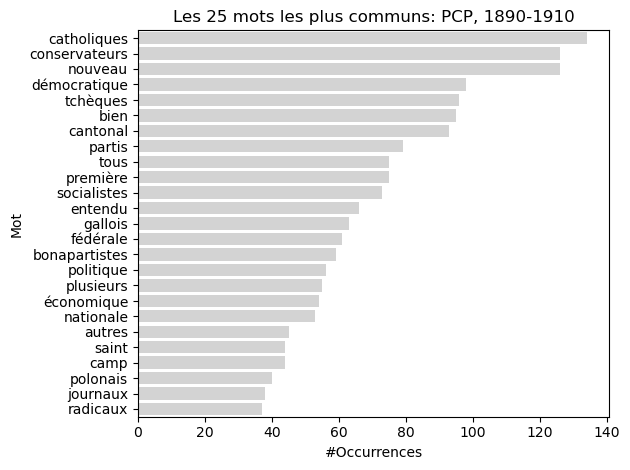

In [ ]:
# Sort data in order of occurences
sorted_data = sorted(zip(occurence_df.index, occurence_df.tot_occurences), key=lambda x: x[1], reverse=True)
# # Filter out words that are 4 characters long or less
filtered_data = [(word, occ) for word, occ in sorted_data if len(word) > 3]
# # Select the top 50 words from the filtered data
# selected_data = filtered_data[:50]
selected_data = filtered_data[:25]

categories, values = zip(*selected_data)
categories,values=list(categories), list(values)

# Set bar color based on the party
bar_color = 'lightgray'  # default color
if party == "PSS":
    bar_color = 'lightgreen'
elif party == "PRD":
    bar_color = 'lightblue'
elif party in ["PPC", "PDC", "PCP"]:
    bar_color = 'orchid'
elif party in ["PAB", "UDC"]:
    bar_color = 'peru'

p = sns.barplot(y=categories, x=values, palette=[bar_color] * len(values) )
p.set_title(f'Les 25 mots les plus communs: {party}, {year}')
p.set_ylabel('Mot')
p.set_xlabel('#Occurrences')

# Adjust layout to ensure nothing is cut off
plt.tight_layout()

# Specify the location and filename for saving the plot
save_path = results_data+f'/overall50_{year}_{party}_allqueries.png'
# Save the plot to the specified location and filename
plt.savefig(save_path)

plt.show()

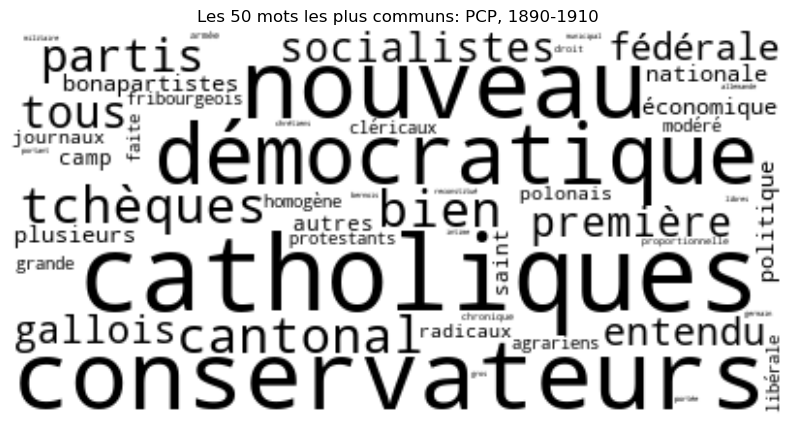

In [ ]:
import random
#Top 50
fig, axs=plt.subplots(1,1, sharex=True, sharey=True, figsize=(10,10))


# Convert selected_data to a dictionary mapping words to their frequencies
selected_data = filtered_data[:50]
word_freq = {word[0]: word[1] for word in selected_data}

# Create a text string for the WordCloud, considering word frequencies
text = " ".join([(k + " ") * int(v) for k, v in word_freq.items()])

# Function to create a colormap with shades of the base color
def create_shades_colormap(base_color):
    base_color = np.array(base_color)
    colors = [base_color * (1 - i / 10) for i in range(10)]
    colors = [(min(1, max(0, c[0])), min(1, max(0, c[1])), min(1, max(0, c[2]))) for c in colors]
    return LinearSegmentedColormap.from_list("custom_shades_colormap", colors, N=256)


# Define base colors for each party
base_colors = {
    'PSS': (144/255, 238/255, 144/255),  # lightgreen
    'PRD': (173/255, 216/255, 230/255),  # lightblue
    'PPC': (218/255, 112/255, 214/255),  # orchid
    'PDC': (218/255, 112/255, 214/255),  # orchid
    'PAB': (205/255, 133/255, 63/255),   # peru
    'UDC': (205/255, 133/255, 63/255)    # peru
}

# Select the appropriate base color
base_color = base_colors.get(party, (0, 0, 0))  # default to black if party not found

# Create the colormap
custom_colormap = create_shades_colormap(base_color)

# Create the WordCloud object
wordcloud = WordCloud(collocations=False, background_color="white", colormap=custom_colormap).generate_from_frequencies(word_freq)

# Plot the WordCloud
# fig, axs = plt.subplots(1, 1, figsize=(10, 8))
axs.imshow(wordcloud, interpolation='bilinear')
axs.axis("off")
axs.set_title(f'Les 50 mots les plus communs: {party}, {year}')

# Specify the location and filename for saving the plot
save_path = results_data + f'/topCloud_{year}_{party}_allqueries.png'

# Save the plot to the specified location and filename
fig.savefig(save_path)

# Show the plot
plt.show()

In [ ]:
# fig, axs=plt.subplots(1,2, sharex=True, sharey=True, figsize=(20,20))
# #Token -1
# sorted_data = sorted(zip(occurence_df.index, occurence_df[N_token-1]), key=lambda x: x[1], reverse=True)
# # Filter out words that are 4 characters long or less
# filtered_data = [(word, occ) for word, occ in sorted_data if len(word) > 4]
# # Select the top 10 words from the filtered data
# selected_data = filtered_data[:50]

# # # Apply the sentiment analysis function to each word in selected_data
# # senti_list = [analyze_sentiment(word[0]) for word in selected_data]

# # # Convert senti_list to a dictionary mapping words to their sentiments
# # word_sentiment_dict = dict(zip([word[0] for word in selected_data], senti_list))


# # Convert selected_data to a dictionary mapping words to their frequencies
# word_freq = {word[0]: word[1] for word in selected_data}

# # Create a text string for the WordCloud, considering word frequencies
# text = " ".join([(k + " ")*int(v) for k, v in word_freq.items()])

# # Create the WordCloud object
# wordcloud = WordCloud(collocations=False, background_color="white").generate_from_frequencies(word_freq)

# # Plot the WordCloud
# axs[0].imshow(wordcloud, interpolation='bilinear')
# axs[0].axis("off")
# axs[0].set_title('Top 50: token -1')

# #Token +1
# sorted_data = sorted(zip(occurence_df.index, occurence_df[N_token+1]), key=lambda x: x[1], reverse=True)
# # Filter out words that are 4 characters long or less
# filtered_data = [(word, occ) for word, occ in sorted_data if len(word) > 4]
# # Select the top 10 words from the filtered data
# selected_data = filtered_data[:50]

# # # Apply the sentiment analysis function to each word in selected_data
# # senti_list = [analyze_sentiment(word[0]) for word in selected_data]

# # # Convert senti_list to a dictionary mapping words to their sentiments
# # word_sentiment_dict = dict(zip([word[0] for word in selected_data], senti_list))


# # Convert selected_data to a dictionary mapping words to their frequencies
# word_freq = {word[0]: word[1] for word in selected_data}

# # Create a text string for the WordCloud, considering word frequencies
# text = " ".join([(k + " ")*int(v) for k, v in word_freq.items()])

# # Create the WordCloud object
# wordcloud2 = WordCloud(collocations=False, background_color="white").generate_from_frequencies(word_freq)

# axs[1].imshow(wordcloud2, interpolation='bilinear')
# axs[1].axis("off")
# axs[1].set_title('Top 50: token +1')
# plt.show()

# # Specify the location and filename for saving the plot
# save_path = results_data + f'/1Cloud_{year}_{party}_allqueries.png'
# # Save the plot to the specified location and filename
# fig.savefig(save_path)

In [ ]:
# fig, axs=plt.subplots(1,2, sharex=True, sharey=True, figsize=(20,25))
# #Token -2
# sorted_data = sorted(zip(occurence_df.index, occurence_df[N_token-2]), key=lambda x: x[1], reverse=True)
# # Filter out words that are 4 characters long or less
# filtered_data = [(word, occ) for word, occ in sorted_data if len(word) > 4]
# # Select the top 10 words from the filtered data
# selected_data = filtered_data[:50]

# # # Apply the sentiment analysis function to each word in selected_data
# # senti_list = [analyze_sentiment(word[0]) for word in selected_data]

# # # Convert senti_list to a dictionary mapping words to their sentiments
# # word_sentiment_dict = dict(zip([word[0] for word in selected_data], senti_list))


# # Convert selected_data to a dictionary mapping words to their frequencies
# word_freq = {word[0]: word[1] for word in selected_data}

# # Create a text string for the WordCloud, considering word frequencies
# text = " ".join([(k + " ")*int(v) for k, v in word_freq.items()])

# # Create the WordCloud object
# wordcloud = WordCloud(collocations=False, background_color="white").generate_from_frequencies(word_freq)

# axs[0].imshow(wordcloud, interpolation='bilinear')
# axs[0].axis("off")
# axs[0].set_title('Top 50: token -2')

# #Token +2
# sorted_data = sorted(zip(occurence_df.index, occurence_df[N_token+2]), key=lambda x: x[1], reverse=True)
# # Filter out words that are 4 characters long or less
# filtered_data = [(word, occ) for word, occ in sorted_data if len(word) > 4]
# # Select the top 10 words from the filtered data
# selected_data = filtered_data[:50]

# # # Apply the sentiment analysis function to each word in selected_data
# # senti_list = [analyze_sentiment(word[0]) for word in selected_data]

# # # Convert senti_list to a dictionary mapping words to their sentiments
# # word_sentiment_dict = dict(zip([word[0] for word in selected_data], senti_list))


# # Convert selected_data to a dictionary mapping words to their frequencies
# word_freq = {word[0]: word[1] for word in selected_data}

# # Create a text string for the WordCloud, considering word frequencies
# text = " ".join([(k + " ")*int(v) for k, v in word_freq.items()])

# # Create the WordCloud object
# wordcloud2 = WordCloud(collocations=False, background_color="white").generate_from_frequencies(word_freq)

# axs[1].imshow(wordcloud2, interpolation='bilinear')
# axs[1].axis("off")
# axs[1].set_title('Top 50:  token +2')
# plt.show()

# # Specify the location and filename for saving the plot
# save_path = results_data + f'/2Cloud_{year}_{party}_allqueries.png'
# # Save the plot to the specified location and filename
# fig.savefig(save_path)

## Graph connections

In [ ]:
# # Filter out titles

# titles = [
#         "président",
#         "député",
#         "roi",
#         "reine",
#         "princesse",
#         "prince",
#         "accusé",
#         "candidat",
#         "ministre",
#         "secrétaire",
#         "chef",
#         "pharmacien",
#         "major",
#         "concurrent",
#         "capitaine",
#         "colonel",
#         "lieutenant",
#         "duc",
#         "empereur",
#         "juge",
#         "avocat",
#         "conseiller",
#         "directeur",
#         "comte"
#     ]

# def filter_titles(names):
#     filtered_names = []
#     for name in names:
#         words = name.split()
#         filtered_words = [word if word.lower() not in titles else '' for word in words]
#         filtered_name = ' '.join(filtered_words).strip()
#         filtered_names.append(filtered_name)
#     return filtered_names


In [ ]:
# #Retrieve all the occurences
# persons=extraction.persons_mentioned
# parsed_names_list=[]

# for person_list in persons:
#     if isinstance(person_list, list):  # Check if it's a list
#         for person in person_list:
#             parsed_name = re.split(r',', str(person).lower())[0]
#             parsed_names_list.append(parsed_name)

# parsed_names_list = [names.split('|') for names in parsed_names_list]
# name_all=np.concatenate(parsed_names_list, axis=0)

# name_all = filter_titles(name_all)
# print('Amount of cited names:',len(name_all))

In [ ]:
# #Build the unique nodes
# nodes= set()
# # Iterate over the matrix and add strings to the set
# for i in range(0,len(name_all)):
#         if(name_all[i]!='nan'):
#                 nodes.add(name_all[i])

# # Convert the set to a list if needed
# nodes = list(nodes)
# print('Amount of unique names:',len(nodes))

In [ ]:
# #Compute the frequency of occurences of each unique name
# freq=np.zeros(len(nodes))
# for i in range(0, len(nodes)):
#     node=nodes[i]
#     for parsed in parsed_names_list:
#         for name in parsed:
#             if node==name and node !='nan':
#                 freq[i]=freq[i]+1


In [ ]:
# #Retrieve the top 50 based on their frequency
# n=10
# sorted_data = sorted(zip(nodes,freq ), key=lambda x: x[1], reverse=True)[:n]
# nodes_top, nodes_freq_top = zip(*sorted_data)
# nodes_top, nodes_freq_top=list(nodes_top), list(nodes_freq_top)

In [ ]:
# Adajacency_matrix_weighted=np.zeros((len(nodes_top),len(nodes_top)))
# Adajacency_matrix=np.zeros((len(nodes_top),len(nodes_top)))
# print("nodes_top is ", nodes_top)
# for node in nodes_top:
#     for parsed in parsed_names_list:
#         if(node in parsed):
#             for name in parsed:
#                 if(name in nodes_top):
#                     index_col=[index for index, value in enumerate(nodes_top) if value == name][0]
#                     index_row=[index for index, value in enumerate(nodes_top) if value == node][0]
#                     Adajacency_matrix_weighted[index_row, index_col]+=1
#                     Adajacency_matrix[index_row, index_col]=1
# print(Adajacency_matrix_weighted)
# print(Adajacency_matrix)
# np.fill_diagonal(Adajacency_matrix_weighted, 0)
# np.fill_diagonal(Adajacency_matrix, 0)
# print(Adajacency_matrix_weighted)
# print(Adajacency_matrix)


In [ ]:
# plt.imshow(Adajacency_matrix, cmap='hot')
# plt.colorbar()
# plt.title(f'Adjacency matrix of the top {n} nodes')

# # Specify the location and filename for saving the plot
# save_path = results_data + f'/Adjacency_{year}_{party}_{query}.png'
# # Save the plot to the specified location and filename
# plt.savefig(save_path)

# plt.show()

In [ ]:
# mapping={}
# for i in range(0, len(nodes_top)):
#     mapping[i]=nodes_top[i]


# G=nx.from_numpy_array(Adajacency_matrix_weighted, )
# G=nx.relabel_nodes(G, mapping)
# edgewidth=np.array([u[2]['weight'] for u in G.edges(data=True)])

# fig, ax = plt.subplots(figsize=(10, 7))
# pos=nx.circular_layout(G)
# nx.draw_networkx_edges(G, pos, alpha=0.3,width=edgewidth/10, edge_color="#0b5ff1")
# nx.draw_networkx_nodes(G, pos, node_size=nodes_freq_top,node_color="#f10b35", alpha=0.9)
# label_options = {"ec": "k", "fc": "white", "alpha": 0.8}
# nx.draw_networkx_labels(G, pos, font_size=14, bbox=label_options)

# ax.margins(0.1, 0.05)
# fig.tight_layout()
# plt.axis("off")
# ax.set_title("10 most represented figures",fontweight='bold')

# # Specify the location and filename for saving the plot
# save_path = results_data + f'/Network_{year}_{party}_{query}.png'
# # Save the plot to the specified location and filename
# fig.savefig(save_path)

# plt.show()